# **Transformer-Based Offensive Language Detection (TweetEval)**

## **Environment Setup and Imports**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required libraries
!pip install -q datasets transformers sentence-transformers matplotlib seaborn vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.2 MB/s eta 0:00:00


In [3]:
# Core libraries
import os
import pandas as pd
import numpy as np
from collections import Counter
import time
import json
import joblib
import shutil

# Dataset loader
from datasets import load_dataset

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text Pre-processing
import re
import nltk
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download required NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")

# Embeddings and models
import torch
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, confusion_matrix,
    roc_curve, auc, roc_auc_score
)

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Device check
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Enable inline plotting
%matplotlib inline

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Using device: cuda


## **1. Data Exploration**

### **1.1 Load TweetEval Dataset**

In [4]:
# Load TweetEval offensive language data
dataset = load_dataset("tweet_eval", "offensive")

train_ds = dataset["train"]
val_ds   = dataset["validation"]
test_ds  = dataset["test"]

dataset

README.md: 0.00B [00:00, ?B/s]

offensive/train-00000-of-00001.parquet:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

offensive/test-00000-of-00001.parquet:   0%|          | 0.00/93.7k [00:00<?, ?B/s]

offensive/validation-00000-of-00001.parq(…):   0%|          | 0.00/122k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11916 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/860 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1324 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 11916
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 860
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1324
    })
})

### **1.2 Convert Dataset to DataFrames**

In [5]:
# Convert HuggingFace dataset to pandas DataFrames
train_df = train_ds.to_pandas()
val_df   = val_ds.to_pandas()
test_df  = test_ds.to_pandas()

train_df.head()

,text,label
0,@user Bono... who cares. Soon people will unde...,0
1,@user Eight years the republicans denied obama...,1
2,@user Get him some line help. He is gonna be j...,0
3,@user @user She is great. Hi Fiona!,0
4,@user She has become a parody unto herself? Sh...,1


### **1.3 Dataset Structure and Size Check**

In [6]:
# Column structure
train_df.columns

Index(['text', 'label'], dtype='object')

In [7]:
# Dataset sizes
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 11916
Validation size: 1324
Test size: 860


### **1.4 Label Mapping**

In [8]:
# Map numeric labels to class names
label_mapping = {
    0: "Not Offensive",
    1: "Offensive"
}

for df in [train_df, val_df, test_df]:
    df["label_name"] = df["label"].map(label_mapping)

### **1.5 Class Distribution Analysis**

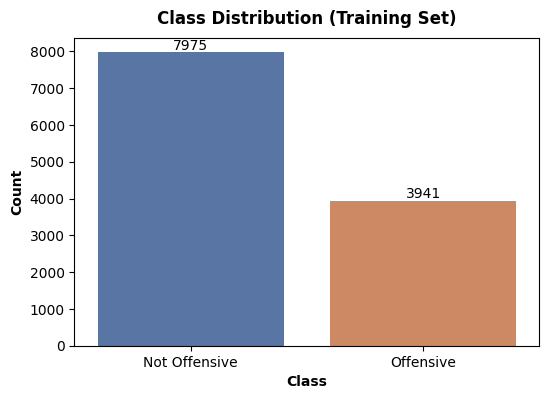

In [9]:
# Class distribution plot with colors and labels
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=train_df,
    x="label_name",
    palette=["#4C72B0", "#DD8452"]
)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Class Distribution (Training Set)", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Class", fontsize=10, fontweight='bold')
plt.ylabel("Count", fontsize=10, fontweight='bold')
plt.show()

### **1.6 Sample Text Inspection**

In [10]:
# Sample tweets per class
for label in train_df["label_name"].unique():
    print(f"\n--- {label} ---")
    print(train_df[train_df["label_name"] == label]["text"].iloc[:3].values)


--- Not Offensive ---
['@user Bono... who cares. Soon people will understand that they gain nothing from following a phony celebrity. Become a Leader of your people instead or help and support your fellow countrymen.'
 '@user Get him some line help. He is gonna be just fine. As the game went on you could see him progressing more with his reads. He brought what has been missing. The deep ball presence. Now he just needs a little more time'
 '@user @user She is great. Hi Fiona!']

--- Offensive ---
['@user Eight years the republicans denied obama’s picks. Breitbarters outrage is as phony as their fake president.'
 "@user She has become a parody unto herself? She has certainly taken some heat for being such an....well idiot. Could be optic too  Who know with Liberals  They're all optics.  No substance"
 '@user Your looking more like a plant #maga #walkaway']


## **2. Tweet Data Preparation**

### **2.1 Text Pre-processing**

In [11]:
# Initialize custom stop words
additional_stop_words = {"amp"}
#additional_stop_words = {"ho", "yo", "amp"}

# Clean and normalize tweet text

def clean_tweet(tweet):
    tweet = re.sub(r"\bRT\b[\s]+", "", tweet)        # remove RT
    tweet = tweet.lower()                            # lowercase
    tweet = re.sub(r"http\S+|www\S+", "", tweet)     # remove URLs
    tweet = re.sub(r"@\w+", "", tweet)               # remove mentions
    tweet = re.sub(r"#", "", tweet)                  # remove hashtag symbol
    tweet = re.sub(r"\bu\b", "you", tweet)           # expand slang
    tweet = re.sub(r"\bim\b", "i am", tweet)

    tweet = re.sub(r"[^\x00-\x7F]+", "", tweet)      # remove non-ASCII
    tweet = re.sub(r"[\"“”‘’]", "", tweet)           # remove quotes
    tweet = re.sub(r"\d+", "", tweet)                # remove numbers
    tweet = re.sub(r"\s+", " ", tweet).strip()       # normalize spaces

    tokens = word_tokenize(tweet)

    tokens = [
        t for t in tokens
        if t.isalpha()                               # keep alphabetic
        and not re.search(r"(.)\1{2,}", t)           # remove elongated words
        and t not in additional_stop_words
    ]

    return " ".join(tokens)


In [12]:
# Apply preprocessing to all splits
for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["text"].apply(clean_tweet)

### **2.2 Token Length Check After Cleaning**

In [13]:
# Token length after preprocessing
train_df["clean_length"] = train_df["clean_text"].str.split().apply(len)

train_df["clean_length"].describe()

,clean_length
count,11916.000000
mean,19.051863
std,13.771250
min,0.000000
25%,8.000000
50%,15.000000
75%,28.000000
max,63.000000


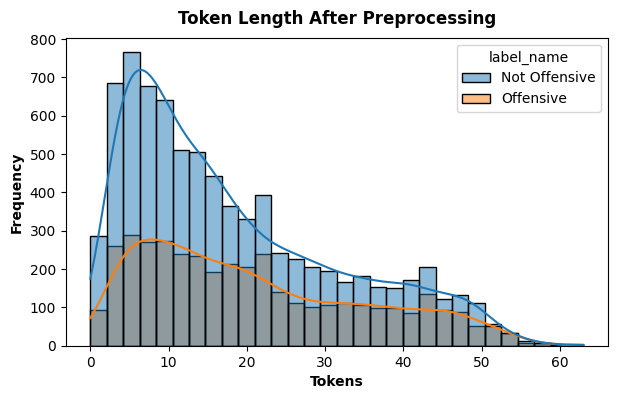

In [14]:
# Distribution after cleaning
plt.figure(figsize=(7,4))
sns.histplot(
    data=train_df,
    x="clean_length",
    hue="label_name",
    bins=30,
    kde=True
)
plt.title("Token Length After Preprocessing", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Tokens", fontsize=10, fontweight='bold')
plt.ylabel("Frequency", fontsize=10, fontweight='bold')
plt.show()

In [15]:
# Explicitly drop tweets having empty strings
for df in [train_df, val_df, test_df]:
    df.dropna(subset=["clean_text"], inplace=True)
    df = df[df["clean_text"].str.strip() != ""]

# Enforce minimum token count (≥ 2 words)
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["token_count"] = df["clean_text"].str.split().apply(len)

train_df = train_df[train_df["token_count"] >= 2]
val_df   = val_df[val_df["token_count"] >= 2]
test_df  = test_df[test_df["token_count"] >= 2]

# Reset indices
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

# Reinspect the cleaned tweets
train_df[["text", "clean_text"]].head(10)

,text,clean_text
0,@user Bono... who cares. Soon people will unde...,bono who cares soon people will understand tha...
1,@user Eight years the republicans denied obama...,eight years the republicans denied obamas pick...
2,@user Get him some line help. He is gonna be j...,get him some line help he is gon na be just fi...
3,@user @user She is great. Hi Fiona!,she is great hi fiona
4,@user She has become a parody unto herself? Sh...,she has become a parody unto herself she has c...
5,@user @user @user @user @user @user @user @use...,this is the vetsresistsquadron is bullshit the...
6,@user Your looking more like a plant #maga #wa...,your looking more like a plant maga walkaway
7,@user @user Lol. Except he’s the most successf...,lol except hes the most successful president i...
8,@user Been a Willie fan since before most of y...,been a willie fan since before most of you wer...
9,@user Here's a link to my channel with a pleth...,here a link to my channel with a plethora of t...


## **3. Exploratory Data Analysis**

### **3.1 Word Frequency Analysis**

In [16]:
# Combine all cleaned tweets
all_words = " ".join(train_df["clean_text"])

# Tokenize
tokens = all_words.split()

# Bag-of-Words frequency
bow = Counter(tokens)

bow.most_common(20)

[('the', 8114),
 ('is', 5938),
 ('to', 5585),
 ('you', 5030),
 ('a', 4869),
 ('and', 4595),
 ('of', 3441),
 ('are', 3282),
 ('i', 3150),
 ('he', 2632),
 ('that', 2596),
 ('in', 2426),
 ('for', 2246),
 ('she', 2210),
 ('it', 2152),
 ('this', 1652),
 ('not', 1529),
 ('on', 1510),
 ('they', 1439),
 ('have', 1337)]

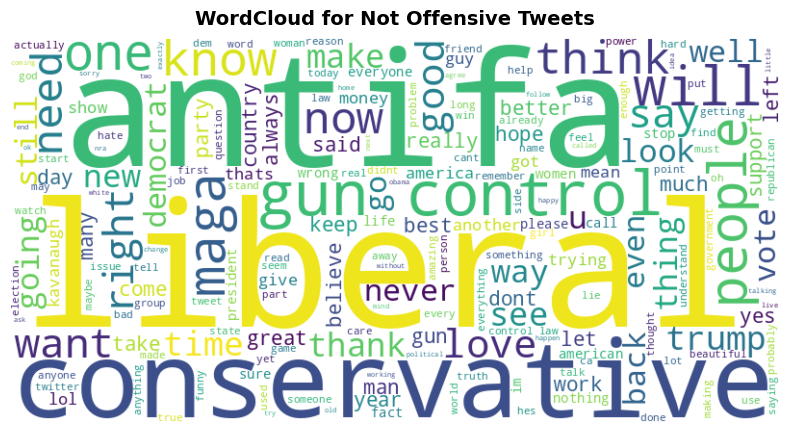

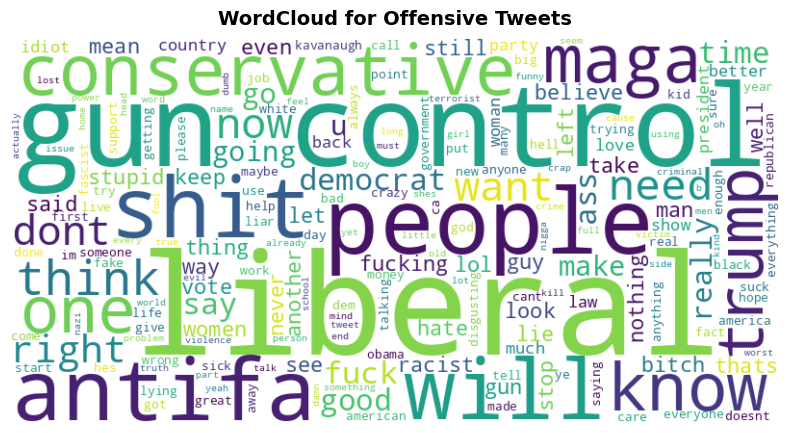

In [17]:
# Class labels
class_labels = {
    0: "Not Offensive",
    1: "Offensive"
}

# Generate WordCloud per class
for label, class_name in class_labels.items():
    class_text = " ".join(
        train_df[train_df["label"] == label]["clean_text"]
    )

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=200
    ).generate(class_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"WordCloud for {class_name} Tweets", fontsize=14, fontweight='bold', pad=10)
    plt.axis("off")
    plt.show()

### **3.2 Cleaned Tweet Statistics Analysis**

In [18]:
# Character length of cleaned tweets
train_df["tweet_length"] = train_df["clean_text"].apply(len)

# Aggregate statistics by class
length_stats = (
    train_df
    .groupby("label_name")["tweet_length"]
    .agg(["min", "max", "mean", "median"])
)

# Compute mode tweet length per class
mode_stats = (
    train_df
    .groupby("label_name")["tweet_length"]
    .apply(lambda x: x.mode().iloc[0])
)

# Add mode and round mean
length_stats["mode"] = mode_stats
length_stats["mean"] = length_stats["mean"].round(2)

length_stats

,min,max,mean,median,mode
label_name,,,,,
Not Offensive,5,283,99.04,77.0,16
Offensive,5,280,111.73,94.0,23


## **4. Embedding Generation**

### **4.1 Prepare Text Data for Embedding**

In [19]:
# Extract cleaned text
X_train = train_df["clean_text"].tolist()
X_val   = val_df["clean_text"].tolist()
X_test  = test_df["clean_text"].tolist()

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

### **4.2 MiniLM Embeddings**

In [20]:
# Load MiniLM model
minilm_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
X_train_minilm = minilm_model.encode(X_train, show_progress_bar=True)
X_val_minilm   = minilm_model.encode(X_val, show_progress_bar=True)
X_test_minilm  = minilm_model.encode(X_test, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/369 [00:00<?, ?it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

### **4.3 DistilBERT Embeddings**

In [21]:
# Load DistilBERT model
distilbert_model = SentenceTransformer("distilbert-base-nli-stsb-mean-tokens")

# Generate embeddings
X_train_distil = distilbert_model.encode(X_train, show_progress_bar=True)
X_val_distil   = distilbert_model.encode(X_val, show_progress_bar=True)
X_test_distil  = distilbert_model.encode(X_test, show_progress_bar=True)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/369 [00:00<?, ?it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

### **4.4 Save Embeddings**

In [22]:
# Create embeddings folder if it does not exist
os.makedirs("/content/drive/MyDrive/OffensEval NLP/embeddings", exist_ok=True)

# Save MiniLM embeddings
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/X_train_minilm.npy", X_train_minilm)
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/X_val_minilm.npy", X_val_minilm)
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/X_test_minilm.npy", X_test_minilm)

# Save DistilBERT embeddings
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/X_train_distil.npy", X_train_distil)
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/X_val_distil.npy", X_val_distil)
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/X_test_distil.npy", X_test_distil)

# Save labels
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/y_train.npy", y_train)
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/y_val.npy", y_val)
np.save("/content/drive/MyDrive/OffensEval NLP/embeddings/y_test.npy", y_test)

## **5. Model Training & Comparison**

### **5.1 Load Embeddings**

In [23]:
base_path = "/content/drive/MyDrive/OffensEval NLP/embeddings"

X_train_minilm = np.load(f"{base_path}/X_train_minilm.npy")
X_val_minilm   = np.load(f"{base_path}/X_val_minilm.npy")

X_train_distil = np.load(f"{base_path}/X_train_distil.npy")
X_val_distil   = np.load(f"{base_path}/X_val_distil.npy")

y_train = np.load(f"{base_path}/y_train.npy")
y_val   = np.load(f"{base_path}/y_val.npy")

### **5.2 Define Classifier and Evaluation Function**

In [24]:
# Train and evaluate classifier
def train_evaluate(X_train, X_val, y_train, y_val):
    model = LogisticRegression(max_iter=1000, n_jobs=-1)

    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_val)

    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
        "train_time": train_time
    }

    return model, metrics

### **5.3 Train Model**

In [25]:
# Train and Evaluate MiniLM Model
minilm_model, minilm_metrics = train_evaluate(
    X_train_minilm,
    X_val_minilm,
    y_train,
    y_val
)

minilm_metrics

{'accuracy': 0.7608861726508785,
 'macro_f1': 0.7118486005509603,
 'train_time': 1.7502751350402832}

In [26]:
# Train and Evaluate DistilBERT Model
distil_model, distil_metrics = train_evaluate(
    X_train_distil,
    X_val_distil,
    y_train,
    y_val
)

distil_metrics

{'accuracy': 0.7517188693659282,
 'macro_f1': 0.7167385432001603,
 'train_time': 2.436978578567505}

In [27]:
# Compare Model Performance
comparison_results = {
    "MiniLM": minilm_metrics,
    "DistilBERT": distil_metrics
}

comparison_results

{'MiniLM': {'accuracy': 0.7608861726508785,
  'macro_f1': 0.7118486005509603,
  'train_time': 1.7502751350402832},
 'DistilBERT': {'accuracy': 0.7517188693659282,
  'macro_f1': 0.7167385432001603,
  'train_time': 2.436978578567505}}

### **5.4 Evaluate Model**

In [28]:
print("MiniLM Classification Report")
print(
    classification_report(
        y_val,
        minilm_model.predict(X_val_minilm),
        digits=4
    )
)

print("\nDistilBERT Classification Report")
print(
    classification_report(
        y_val,
        distil_model.predict(X_val_distil),
        digits=4
    )
)

MiniLM Classification Report
              precision    recall  f1-score   support

           0     0.7719    0.8993    0.8307       854
           1     0.7261    0.5011    0.5930       455

    accuracy                         0.7609      1309
   macro avg     0.7490    0.7002    0.7118      1309
weighted avg     0.7560    0.7609    0.7481      1309


DistilBERT Classification Report
              precision    recall  f1-score   support

           0     0.7891    0.8454    0.8163       854
           1     0.6650    0.5758    0.6172       455

    accuracy                         0.7517      1309
   macro avg     0.7270    0.7106    0.7167      1309
weighted avg     0.7459    0.7517    0.7471      1309



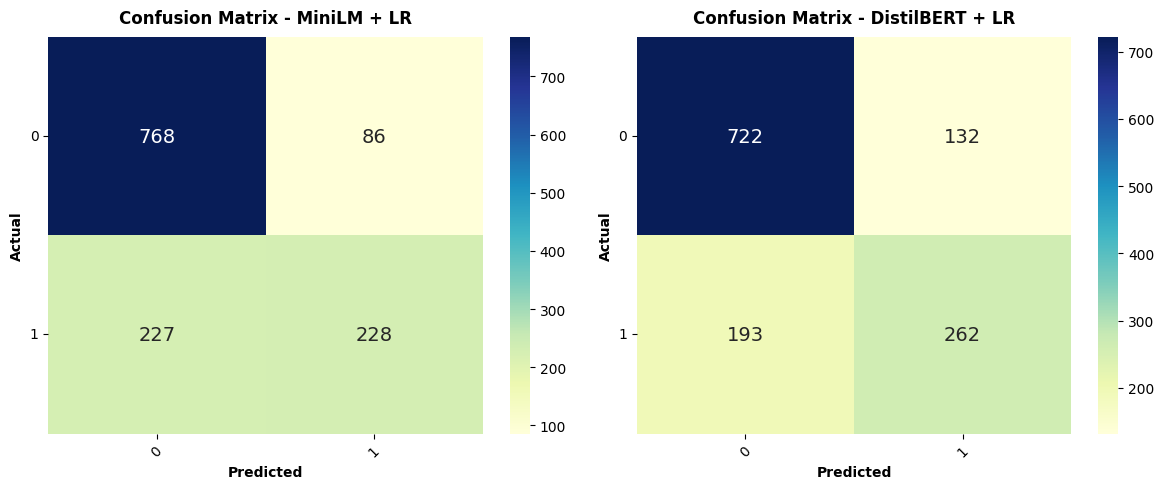

In [29]:
# Predict on validation set
y_pred_minilm = minilm_model.predict(X_val_minilm)
y_pred_distil = distil_model.predict(X_val_distil)

# Confusion matrices
cm_minilm = confusion_matrix(y_val, y_pred_minilm)
cm_distil = confusion_matrix(y_val, y_pred_distil)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MiniLM confusion matrix
sns.heatmap(
    cm_minilm,
    annot=True,
    fmt="g",
    cmap=plt.cm.YlGnBu,
    annot_kws={"size": 14},
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix - MiniLM + LR", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Predicted", fontsize=10, fontweight='bold')
axes[0].set_ylabel("Actual", fontsize=10, fontweight='bold')
axes[0].set_xticklabels(class_labels, rotation=45)
axes[0].set_yticklabels(class_labels, rotation=0)

# DistilBERT confusion matrix
sns.heatmap(
    cm_distil,
    annot=True,
    fmt="g",
    cmap=plt.cm.YlGnBu,
    annot_kws={"size": 14},
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix - DistilBERT + LR", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Predicted", fontsize=10, fontweight='bold')
axes[1].set_ylabel("Actual", fontsize=10, fontweight='bold')
axes[1].set_xticklabels(class_labels, rotation=45)
axes[1].set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()

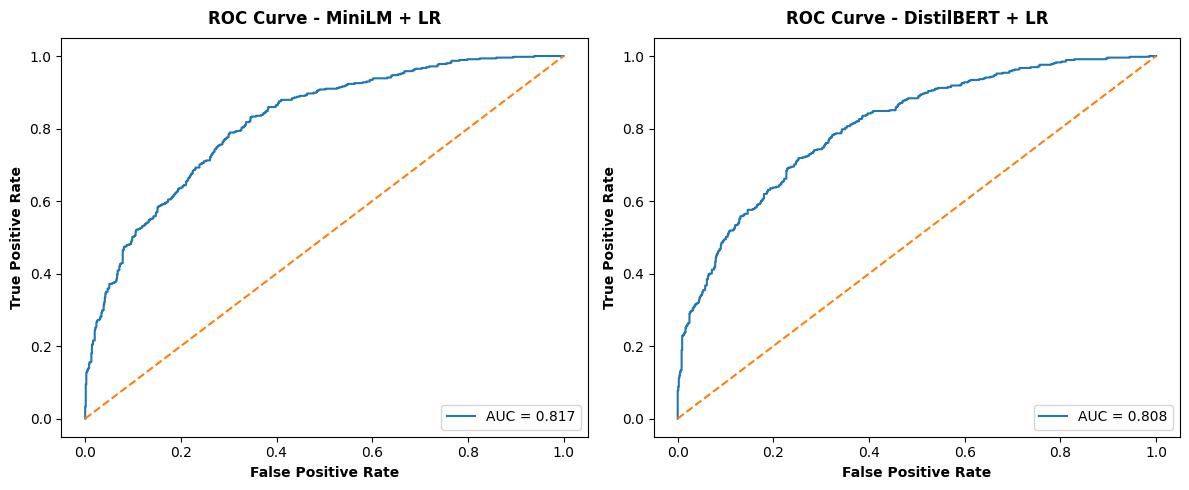

In [30]:
# Predict probabilities for positive class
y_prob_minilm = minilm_model.predict_proba(X_val_minilm)[:, 1]
y_prob_distil = distil_model.predict_proba(X_val_distil)[:, 1]

# ROC curve points
fpr_minilm, tpr_minilm, _ = roc_curve(y_val, y_prob_minilm)
fpr_distil, tpr_distil, _ = roc_curve(y_val, y_prob_distil)

# AUC scores
auc_minilm = auc(fpr_minilm, tpr_minilm)
auc_distil = auc(fpr_distil, tpr_distil)

# Create side-by-side ROC plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MiniLM ROC
axes[0].plot(fpr_minilm, tpr_minilm, label=f"AUC = {auc_minilm:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC Curve - MiniLM + LR", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("False Positive Rate", fontsize=10, fontweight='bold')
axes[0].set_ylabel("True Positive Rate", fontsize=10, fontweight='bold')
axes[0].legend(loc="lower right")

# DistilBERT ROC
axes[1].plot(fpr_distil, tpr_distil, label=f"AUC = {auc_distil:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set_title("ROC Curve - DistilBERT + LR", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("False Positive Rate", fontsize=10, fontweight='bold')
axes[1].set_ylabel("True Positive Rate", fontsize=10, fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## **6. Model Tuning**

### **6.1 Create Sentiment Feature**

In [31]:
# Define function for sentiment analysis
sia = SentimentIntensityAnalyzer()

def extract_sentiment(texts):
    return np.array(
        [sia.polarity_scores(t)["compound"] for t in texts]
    ).reshape(-1, 1)

In [32]:
# Create Sentiment Features
sent_train = extract_sentiment(train_df["clean_text"])
sent_val   = extract_sentiment(val_df["clean_text"])

### **6.2 Combine Features (DistilBERT Embeddings + Sentiment Rating)**

In [33]:
# Augment DistilBERT Embeddings
X_train_distil_aug = np.hstack([X_train_distil, sent_train])
X_val_distil_aug   = np.hstack([X_val_distil, sent_val])

### **6.3 Retraining DistilBERT+LR Classifier**

In [34]:
# Retrain Classifier (DistilBERT + Sentiment)
distil_aug_model, distil_aug_metrics = train_evaluate(
    X_train_distil_aug,
    X_val_distil_aug,
    y_train,
    y_val
)

distil_aug_metrics

{'accuracy': 0.7517188693659282,
 'macro_f1': 0.7191107677782069,
 'train_time': 2.472799301147461}

### **6.4 Tuned Model Evaluation**

In [35]:
print("\nTuned DistilBERT Classification Report")
print(
    classification_report(
        y_val,
        distil_aug_model.predict(X_val_distil_aug),
        digits=4
    )
)


Tuned DistilBERT Classification Report
              precision    recall  f1-score   support

           0     0.7936    0.8372    0.8148       854
           1     0.6593    0.5912    0.6234       455

    accuracy                         0.7517      1309
   macro avg     0.7264    0.7142    0.7191      1309
weighted avg     0.7469    0.7517    0.7483      1309



In [36]:
y_prob_distil_aug = distil_aug_model.predict_proba(X_val_distil_aug)[:, 1]
roc_distil_aug = roc_auc_score(y_val, y_prob_distil_aug)

distil_aug_metrics["roc_auc"] = roc_distil_aug
distil_aug_metrics

{'accuracy': 0.7517188693659282,
 'macro_f1': 0.7191107677782069,
 'train_time': 2.472799301147461,
 'roc_auc': np.float64(0.8099145585094063)}

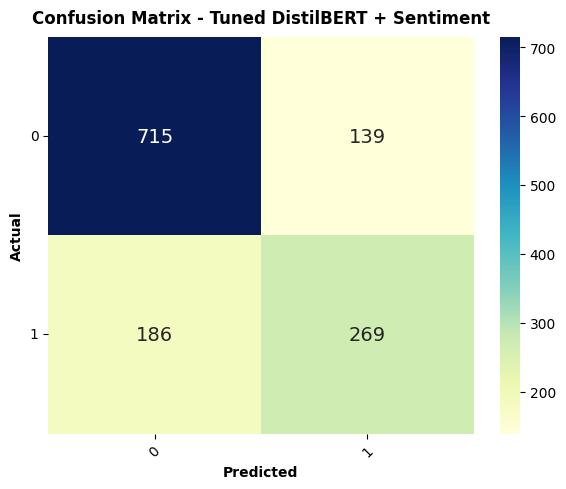

In [37]:
# Predict on validation set
y_pred_distil_aug = distil_aug_model.predict(X_val_distil_aug)

# Confusion matrix
cm_distil_aug = confusion_matrix(y_val, y_pred_distil_aug)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
ax = sns.heatmap(
    cm_distil_aug,
    annot=True,
    fmt="g",
    cmap=plt.cm.YlGnBu,
    annot_kws={"size": 14}
)

ax.set_title("Confusion Matrix - Tuned DistilBERT + Sentiment", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Predicted", fontsize=10, fontweight="bold")
ax.set_ylabel("Actual", fontsize=10, fontweight="bold")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()

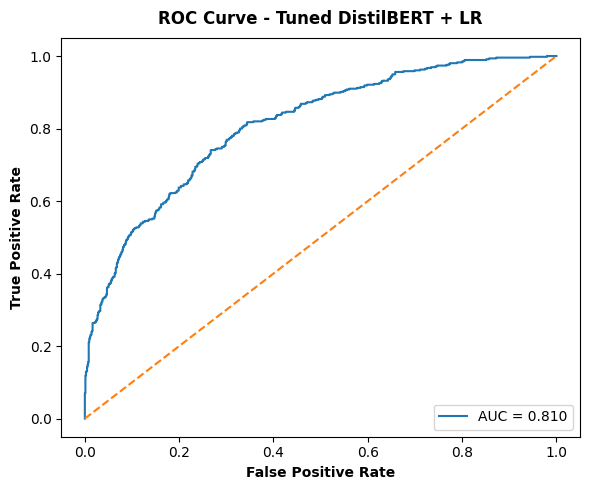

In [38]:
# Predict probabilities for positive class
y_prob_distil_aug = distil_aug_model.predict_proba(X_val_distil_aug)[:, 1]

# ROC curve points
fpr, tpr, _ = roc_curve(y_val, y_prob_distil_aug)

# AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title(
    "ROC Curve - Tuned DistilBERT + LR", fontsize=12, fontweight="bold", pad=10
)
plt.xlabel("False Positive Rate", fontsize=10, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=10, fontweight="bold")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

### **6.5 Final Model Selection**

In [39]:
# Base Models Probabilities
y_prob_minilm = minilm_model.predict_proba(X_val_minilm)[:, 1]
y_prob_distil = distil_model.predict_proba(X_val_distil)[:, 1]

# ROC-AUC for base models
minilm_metrics["roc_auc"] = roc_auc_score(y_val, y_prob_minilm)
distil_metrics["roc_auc"] = roc_auc_score(y_val, y_prob_distil)

# Best Base Model Selection
if (
    minilm_metrics["macro_f1"] > distil_metrics["macro_f1"]
    or (
        minilm_metrics["macro_f1"] == distil_metrics["macro_f1"]
        and minilm_metrics["roc_auc"] >= distil_metrics["roc_auc"]
    )
):
    best_base_name = "MiniLM"
    best_base_model = minilm_model
    best_base_metrics = minilm_metrics
else:
    best_base_name = "DistilBERT"
    best_base_model = distil_model
    best_base_metrics = distil_metrics

In [40]:
# Tuned Model Probabilities
y_prob_distil_tuned = distil_aug_model.predict_proba(X_val_distil_aug)[:, 1]
distil_aug_metrics["roc_auc"] = roc_auc_score(y_val, y_prob_distil_tuned)

# Final Model Selection
if (
    distil_aug_metrics["macro_f1"] > best_base_metrics["macro_f1"]
    or (
        distil_aug_metrics["macro_f1"] == best_base_metrics["macro_f1"]
        and distil_aug_metrics["roc_auc"] >= best_base_metrics["roc_auc"]
    )
):
    final_model_name = "Tuned DistilBERT"
    final_model = distil_aug_model
    final_metrics = distil_aug_metrics
else:
    final_model_name = best_base_name
    final_model = best_base_model
    final_metrics = best_base_metrics

final_model_name, final_metrics

('Tuned DistilBERT',
 {'accuracy': 0.7517188693659282,
  'macro_f1': 0.7191107677782069,
  'train_time': 2.472799301147461,
  'roc_auc': np.float64(0.8099145585094063)})

### **6.6 Save Final Model**

In [41]:
# Base model directory
model_base_path = "/content/drive/MyDrive/OffensEval NLP/model"

# Create model directory
os.makedirs(model_base_path, exist_ok=True)

# Save selected model
joblib.dump(
    final_model,
    f"{model_base_path}/final_model_{final_model_name.lower()}.joblib"
)

# Label mapping
label_encoder = {
    0: "Not Offensive",
    1: "Offensive"
}

# Save label mapping
with open(f"{model_base_path}/label_encoder.json", "w") as f:
    json.dump(label_encoder, f)

# Verify Saved Artifacts
os.listdir(model_base_path)

['final_model_tuned distilbert.joblib', 'label_encoder.json']